In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("churn_2.csv")

In [3]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
encoder = LabelEncoder()
for column in df.columns:

    if df[column].dtype == 'object':

        df[column] = encoder.fit_transform(df[column])

In [5]:
X = df.drop('Churn', axis=1)

y = df['Churn']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [9]:
linear_model = SVC(
    kernel='linear',
    probability=True
)

linear_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [10]:
linear_pred = linear_model.predict(X_test)

In [11]:
print(
    "Linear Accuracy:",
    accuracy_score(y_test, linear_pred)
)

Linear Accuracy: 0.8520599250936329


In [12]:
print(classification_report(y_test, linear_pred))

              precision    recall  f1-score   support

       False       0.85      1.00      0.92       455
        True       0.00      0.00      0.00        79

    accuracy                           0.85       534
   macro avg       0.43      0.50      0.46       534
weighted avg       0.73      0.85      0.78       534



C:\Users\-\Desktop\ml-project\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\-\Desktop\ml-project\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\-\Desktop\ml-project\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [13]:
cm = confusion_matrix(y_test, linear_pred)

print(cm)

[[455   0]
 [ 79   0]]


In [14]:
linear_probs = linear_model.predict_proba(X_test)[:,1]

In [15]:
auc = roc_auc_score(y_test, linear_probs)

print("Linear AUC:", auc)

Linear AUC: 0.6500208652107385


In [16]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    linear_probs
)

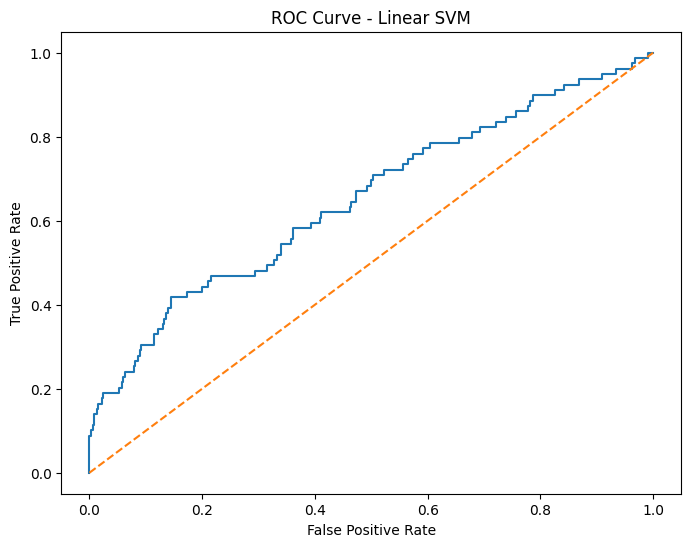

In [17]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Linear SVM")

plt.show()

In [18]:
rbf_model = SVC(
    kernel='rbf',
    probability=True
)

rbf_model.fit(X_train, y_train)

SVC(probability=True)

In [19]:
rbf_pred = rbf_model.predict(X_test)

In [20]:
print(
    "RBF Accuracy:",
    accuracy_score(y_test, rbf_pred)
)

RBF Accuracy: 0.9026217228464419


In [21]:
print(classification_report(y_test, rbf_pred))

              precision    recall  f1-score   support

       False       0.91      0.99      0.95       455
        True       0.85      0.42      0.56        79

    accuracy                           0.90       534
   macro avg       0.88      0.70      0.75       534
weighted avg       0.90      0.90      0.89       534



In [22]:
rbf_probs = rbf_model.predict_proba(X_test)[:,1]

rbf_auc = roc_auc_score(
    y_test,
    rbf_probs
)

print("RBF AUC:", rbf_auc)

RBF AUC: 0.8886354152176937


In [23]:
rbf_probs = rbf_model.predict_proba(X_test)[:,1]

rbf_auc = roc_auc_score(
    y_test,
    rbf_probs
)

print("RBF AUC:", rbf_auc)

RBF AUC: 0.8886354152176937
